**Text Summarization using different methods extractive **

In [ ]:
!pip install sumy

In [ ]:
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
text = """
Artificial intelligence is transforming many areas of modern life.
 It allows computer systems to perform tasks that normally require
  human intelligence, such as learning, reasoning, problem solving,
   and decision making. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation.

Deep learning is a subset of machine learning that uses neural networks
with multiple layers. These models can process large amounts of complex data
and have achieved strong results in image recognition, speech recognition,
and natural language processing. However, training deep learning models often
 requires large datasets and significant computational resources.

Artificial intelligence is widely used in healthcare, education, finance,
transportation, and entertainment. For example, AI systems can help doctors
analyze medical images, recommend personalized learning materials, detect
fraudulent financial transactions, and support autonomous vehicles.
Despite these benefits, the development of AI also raises concerns about
privacy, bias, security, and the responsible use of technology.

Researchers and organizations are working to develop AI systems that are
accurate, reliable, and ethical. As AI technology continues to advance,
understanding its capabilities and limitations will become increasingly
important for individuals and society.
"""

In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from nltk.corpus import stopwords
parser = PlaintextParser.from_string(text, Tokenizer("english"))

summarizer = LexRankSummarizer()
summarizer.epsilon = 0.1
summarizer.threshold = 0.2
summarizer.stop_words = stopwords.words("english")
summary = summarizer(parser.document,2)

for sentence in summary:
    print(sentence)

Artificial intelligence is transforming many areas of modern life.
It allows computer systems to perform tasks that normally require human intelligence, such as learning, reasoning, problem solving, and decision making.


In [ ]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)

summary_length = max(1, int(len(sentences) * 0.3))
summary = summarizer(parser.document, summary_length)

for sentence in summary:
    print(sentence)

Artificial intelligence is transforming many areas of modern life.
It allows computer systems to perform tasks that normally require human intelligence, such as learning, reasoning, problem solving, and decision making.
Machine learning is an important branch of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every situation.


In [ ]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Split text into sentences
sentences = sent_tokenize(text)

# Create TF-IDF matrix
vectorizer = TfidfVectorizer(
    stop_words="english",
    use_idf=True
)

tfidf_matrix = vectorizer.fit_transform(sentences)

# Score each sentence
scores = tfidf_matrix.sum(axis=1).A1

# Select top 5 sentences
top_n = 5
top_indices = scores.argsort()[-top_n:]

# Restore original order
top_indices = sorted(top_indices)

# Generate summary
summary_tfidf = " ".join(sentences[i] for i in top_indices)

print("TF-IDF SUMMARY:\n")
print(summary_tfidf)

TF-IDF SUMMARY:

It allows computer systems to perform tasks that normally require
  human intelligence, such as learning, reasoning, problem solving,
   and decision making. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. These models can process large amounts of complex data
and have achieved strong results in image recognition, speech recognition,
and natural language processing. For example, AI systems can help doctors
analyze medical images, recommend personalized learning materials, detect
fraudulent financial transactions, and support autonomous vehicles. Despite these benefits, the development of AI also raises concerns about
privacy, bias, security, and the responsible use of technology.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Create sentence similarity matrix
similarity_matrix = cosine_similarity(tfidf_matrix)

# Score sentences based on similarity with other sentences
similarity_scores = similarity_matrix.sum(axis=1)

top_n = 5

# Select highest-scoring sentences
top_indices = similarity_scores.argsort()[-top_n:]

# Restore original order
top_indices = sorted(top_indices)

# Create summary
summary_similarity = " ".join(sentences[i] for i in top_indices)

print("\nCOSINE SIMILARITY SUMMARY:\n")
print(summary_similarity)


COSINE SIMILARITY SUMMARY:


Artificial intelligence is transforming many areas of modern life. It allows computer systems to perform tasks that normally require
  human intelligence, such as learning, reasoning, problem solving,
   and decision making. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. Deep learning is a subset of machine learning that uses neural networks
with multiple layers. However, training deep learning models often
 requires large datasets and significant computational resources.


In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

sentences = sent_tokenize(text)

In [ ]:
words = word_tokenize(text.lower())

stop_words = set(stopwords.words("english"))

cleaned_words = [
    word for word in words
    if word.isalpha() and word not in stop_words
]

print(cleaned_words[:20])

['artificial', 'intelligence', 'transforming', 'many', 'areas', 'modern', 'life', 'allows', 'computer', 'systems', 'perform', 'tasks', 'normally', 'require', 'human', 'intelligence', 'learning', 'reasoning', 'problem', 'solving']


In [ ]:
freq = FreqDist(cleaned_words)

print(freq.most_common(10))

[('learning', 6), ('intelligence', 4), ('systems', 4), ('ai', 4), ('artificial', 3), ('machine', 2), ('important', 2), ('data', 2), ('deep', 2), ('models', 2)]


In [ ]:
sentence_scores = []

for sentence in sentences:
    words_in_sentence = word_tokenize(sentence.lower())

    score = sum(
        freq[word]
        for word in words_in_sentence
        if word in freq
    )

    sentence_scores.append(score)

print(sentence_scores)

[12, 26, 32, 22, 21, 20, 14, 30, 17, 15, 17]


In [ ]:
top_n = 5

top_indices = sorted(
    range(len(sentences)),
    key=lambda i: sentence_scores[i],
    reverse=True
)[:top_n]

print(top_indices)

[2, 7, 1, 3, 4]


In [ ]:
top_indices = sorted(top_indices)

summary = " ".join(sentences[i] for i in top_indices)

print("SUMMARY:\n")
print(summary)

SUMMARY:

It allows computer systems to perform tasks that normally require
  human intelligence, such as learning, reasoning, problem solving,
   and decision making. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. Deep learning is a subset of machine learning that uses neural networks
with multiple layers. These models can process large amounts of complex data
and have achieved strong results in image recognition, speech recognition,
and natural language processing. For example, AI systems can help doctors
analyze medical images, recommend personalized learning materials, detect
fraudulent financial transactions, and support autonomous vehicles.


In [ ]:
sentence_scores = []

for sentence in sentences:
    words_in_sentence = word_tokenize(sentence.lower())

    score = sum(
        freq[word]
        for word in words_in_sentence
        if word in freq
    )

    normalized_score = score / len(words_in_sentence)

    sentence_scores.append(normalized_score)

print(sentence_scores)

[1.2, 1.0, 1.28, 1.375, 0.8076923076923077, 1.3333333333333333, 0.8235294117647058, 1.1111111111111112, 0.68, 0.8333333333333334, 0.8095238095238095]


In [ ]:
# Select top 5 sentences using the new scores
top_n = 5

top_indices = sorted(
    range(len(sentences)),
    key=lambda i: sentence_scores[i],
    reverse=True
)[:top_n]

# Restore original order
top_indices = sorted(top_indices)

# Create and print summary
summary_average = " ".join(sentences[i] for i in top_indices)

print("AVERAGE FREQUENCY SUMMARY:\n")
print(summary_average)

AVERAGE FREQUENCY SUMMARY:


Artificial intelligence is transforming many areas of modern life. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. Deep learning is a subset of machine learning that uses neural networks
with multiple layers. However, training deep learning models often
 requires large datasets and significant computational resources. For example, AI systems can help doctors
analyze medical images, recommend personalized learning materials, detect
fraudulent financial transactions, and support autonomous vehicles.


In [ ]:
sentence_scores = []

for sentence in sentences:
    words_in_sentence = [
        word for word in word_tokenize(sentence.lower())
        if word in freq
    ]

    if words_in_sentence:
        score = max(freq[word] for word in words_in_sentence)
    else:
        score = 0

    sentence_scores.append(score)

print(sentence_scores)

[4, 6, 6, 6, 2, 6, 4, 6, 4, 4, 4]


In [ ]:
top_n = 5

top_indices = sorted(
    range(len(sentences)),
    key=lambda i: sentence_scores[i],
    reverse=True
)[:top_n]

top_indices = sorted(top_indices)

summary_max = " ".join(sentences[i] for i in top_indices)

print("MAX FREQUENCY SUMMARY:\n")
print(summary_max)

MAX FREQUENCY SUMMARY:

It allows computer systems to perform tasks that normally require
  human intelligence, such as learning, reasoning, problem solving,
   and decision making. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. Deep learning is a subset of machine learning that uses neural networks
with multiple layers. However, training deep learning models often
 requires large datasets and significant computational resources. For example, AI systems can help doctors
analyze medical images, recommend personalized learning materials, detect
fraudulent financial transactions, and support autonomous vehicles.


**abstractive summary**

Beyond `max_length` and `min_length`, here are some other important parameters you can fine-tune in `model.generate()` to influence the quality and style of the generated summary:

*   `do_sample` (bool, default `False`): Whether to use sampling. If `False`, uses greedy decoding. Set to `True` for more diverse outputs.
*   `num_beams` (int, default `1`): Number of beams for beam search. A higher number generally leads to higher quality but slower generation. It's often set to `4` or `5`.
*   `temperature` (float, default `1.0`): The value used to modulate the next token probabilities. Lower values make the model more confident and less risky; higher values increase randomness.
*   `top_k` (int, default `50`): The number of highest probability vocabulary tokens to keep for top-k-filtering. Only effective when `do_sample=True`.
*   `top_p` (float, default `1.0`): If set to a float < 1, only the most probable tokens with probabilities that add up to `top_p` are kept for generation. Only effective when `do_sample=True`.
*   `repetition_penalty` (float, default `1.0`): The parameter used to penalize new tokens based on whether they appear in the text already. Higher values discourage repetition.
*   `no_repeat_ngram_size` (int, default `0`): All ngrams of this size can only occur once in the summary. A common value is `3` to avoid repetitive phrases.
*   `early_stopping` (bool, default `False`): Whether to stop generation once all beam candidates have reached their `eos_token_id`.

Experimenting with these parameters allows you to control the trade-off between coherence, relevance, and creativity of the generated summaries.

In [ ]:
!pip install -q torch torchvision transformers sentencepiece


In [ ]:
import torch
import torchvision
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [ ]:
model_name = "sshleifer/distilbart-cnn-12-6"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.22GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

In [ ]:
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

In [ ]:
output = model.generate(
    **inputs,
    max_length=100,
    min_length=30
)

In [ ]:
summary = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("ABSTRACTIVE SUMMARY:\n")
print(summary)

ABSTRACTIVE SUMMARY:

 Machine learning is an important branch of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every situation . Deep learning is a subset of machine learning that uses neural networks with multiple layers . The development of AI raises concerns about privacy, bias, security and the responsible use of technology .


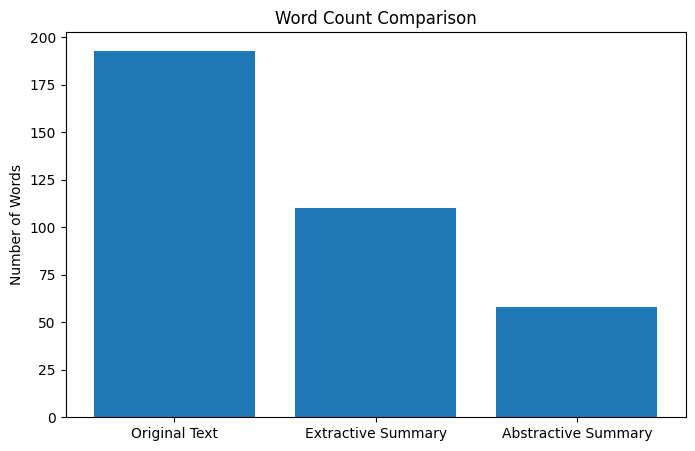

In [ ]:
import matplotlib.pyplot as plt

original_words = len(text.split())
extractive_words = len(summary_tfidf.split())
abstractive_words = len(summary.split())

plt.figure(figsize=(8, 5))

plt.bar(
    ["Original Text", "Extractive Summary", "Abstractive Summary"],
    [original_words, extractive_words, abstractive_words]
)

plt.title("Word Count Comparison")
plt.ylabel("Number of Words")
plt.show()

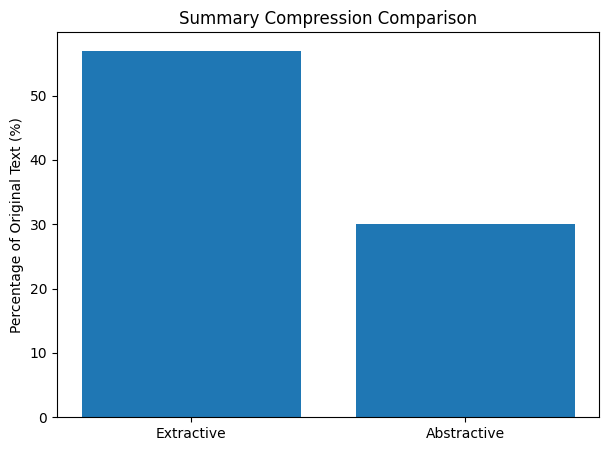

In [ ]:
import matplotlib.pyplot as plt

original_words = len(text.split())

extractive_percentage = (
    len(summary_tfidf.split()) / original_words
) * 100

abstractive_percentage = (
    len(summary.split()) / original_words
) * 100

plt.figure(figsize=(7, 5))

plt.bar(
    ["Extractive", "Abstractive"],
    [extractive_percentage, abstractive_percentage]
)

plt.title("Summary Compression Comparison")
plt.ylabel("Percentage of Original Text (%)")
plt.show()

In [ ]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Split paragraph into sentences
sentences = sent_tokenize(text)

# Query
query = "How is artificial intelligence used in different fields?"

# Combine sentences and query for TF-IDF
documents = sentences + [query]

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(documents)

# Last vector is the query
query_vector = tfidf_matrix[-1]

# Compare query with every sentence
similarity_scores = cosine_similarity(
    tfidf_matrix[:-1],
    query_vector
).flatten()

# Select top 3 sentences
top_n = 3
top_indices = similarity_scores.argsort()[-top_n:]

# Restore original order
top_indices = sorted(top_indices)

# Create summary
query_summary = " ".join(
    sentences[i] for i in top_indices
)

print("QUERY-FOCUSED SUMMARY:\n")
print(query_summary)

QUERY-FOCUSED SUMMARY:


Artificial intelligence is transforming many areas of modern life. Machine learning is an important branch of
   artificial intelligence that enables systems to learn patterns from
   data without being explicitly programmed for every situation. Artificial intelligence is widely used in healthcare, education, finance,
transportation, and entertainment.


In [ ]:
import time

start = time.time()
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-cnn-12-6"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Create input
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

# Generate very short summary
output = model.generate(
    **inputs,
    max_length=40,
    min_length=5
)

# Convert generated tokens to text
headline = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("HEADLINE SUMMARY:\n")
print(headline)
end = time.time()

print("Execution time:", end - start, "seconds")

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

HEADLINE SUMMARY:

 Machine learning is an important branch of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every situation . Deep learning is a subset of machine learning that uses neural networks
Execution time: 13.416501760482788 seconds


In [ ]:
import time

start = time.time()
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-cnn-12-6"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Create input
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

# Generate very short summary
output = model.generate(
    **inputs,
    max_length=40,
    min_length=5,
    num_beams=5
)
# Convert generated tokens to text
headline = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("HEADLINE SUMMARY:\n")
print(headline)
end = time.time()

print("Execution time:", end - start, "seconds")

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

HEADLINE SUMMARY:

 Machine learning is an important branch of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every situation . Deep learning is a subset of machine learning that uses neural networks
Execution time: 10.596248149871826 seconds


**corpus text summarization**

In [1]:
import nltk
nltk.download('brown')
nltk.download('punkt_tab')

from nltk.corpus import brown

# Get sentences from Brown Corpus
sentences = brown.sents(categories='news')

# Convert words into sentences
text = " ".join([" ".join(sentence) for sentence in sentences[:50]])

print(text)

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. . `` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' . The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous '' . It recommended that Fulton legislators act `` to have th

[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

sentences = sent_tokenize(text)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sentences)

scores = tfidf_matrix.sum(axis=1).A1

top_n = 5
top_indices = scores.argsort()[-top_n:]
top_indices = sorted(top_indices)

summary = " ".join(sentences[i] for i in top_indices)

print("EXTRACTIVE SUMMARY:")
print(summary)

EXTRACTIVE SUMMARY:
The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. . The grand jury commented on a number of other topics , among them the Atlanta and Fulton County purchasing departments which it said `` are well operated and follow generally accepted practices which inure to the best interest of both governments '' . `` This is one of the major items in the Fulton County general assistance program '' , the jury said , but the State Welfare Department `` has seen fit to distribute these funds through the welfare departments of all the counties in the state with the exception of Fulton County , which receives none of this money . Wards protected The jury said it found the court `` has incorporated into its operating procedures the recommendations '' of two previous grand juries , the Atlanta Bar Association and an

In [3]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(sentences)

similarity_matrix = cosine_similarity(tfidf)

graph = nx.from_numpy_array(similarity_matrix)
scores = nx.pagerank(graph)

top_indices = sorted(
    sorted(scores, key=scores.get, reverse=True)[:5]
)

textrank_summary = " ".join(sentences[i] for i in top_indices)

print("TEXTRANK SUMMARY:")
print(textrank_summary)

TEXTRANK SUMMARY:
The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . The grand jury commented on a number of other topics , among them the Atlanta and Fulton County purchasing departments which it said `` are well operated and follow generally accepted practices which inure to the best interest of both governments '' . `` This is one of the major items in the Fulton County general assistance program '' , the jury said , but the State Welfare Department `` has seen fit to distribute these funds through the welfare departments of all the counties in the state with the exception of Fulton County , which receives none of this money . Mayor William 

In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

inputs = tokenizer(
    "summarize: " + text,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

output = model.generate(
    **inputs,
    max_length=100,
    min_length=30,
    num_beams=4
)

summary = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("ABSTRACTIVE SUMMARY:")
print(summary)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

ABSTRACTIVE SUMMARY:
Fulton County Grand Jury said the investigation of Atlanta's recent primary election produced '' no evidence '' that any irregularities took place .


In [5]:
import nltk
nltk.download('brown')
nltk.download('punkt_tab')

from nltk.corpus import brown
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Take text from Brown Corpus
brown_sentences = brown.sents(categories='news')[:100]

text = " ".join(" ".join(sentence) for sentence in brown_sentences)

# Split into sentences
sentences = sent_tokenize(text)

# Query
query = "What are the main events and important information?"

# Combine sentences and query
documents = sentences + [query]

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

# Query vector
query_vector = tfidf_matrix[-1]

# Calculate cosine similarity
scores = cosine_similarity(
    tfidf_matrix[:-1],
    query_vector
).flatten()

# Metric tuning: try different numbers of sentences
for top_n in [3, 5, 7, 10]:

    top_indices = scores.argsort()[-top_n:]
    top_indices = sorted(top_indices)

    summary = " ".join(sentences[i] for i in top_indices)

    print("\n================================")
    print("TOP N =", top_n)
    print("================================")
    print(summary)


TOP N = 3
`` There wasn't a bit of trouble '' . Austin , Texas -- Committee approval of Gov. Price Daniel's `` abandoned property '' act seemed certain Thursday despite the adamant protests of Texas bankers .

TOP N = 5
Sheriff Felix Tabb said the ordinary apparently made good his promise . `` Everything went real smooth '' , the sheriff said . `` There wasn't a bit of trouble '' . Austin , Texas -- Committee approval of Gov. Price Daniel's `` abandoned property '' act seemed certain Thursday despite the adamant protests of Texas bankers .

TOP N = 7
Ordinary Williams said he , too , was subjected to anonymous calls soon after he scheduled the election . Many local citizens feared that there would be irregularities at the polls , and Williams got himself a permit to carry a gun and promised an orderly election . Sheriff Felix Tabb said the ordinary apparently made good his promise . `` Everything went real smooth '' , the sheriff said . `` There wasn't a bit of trouble '' . Austin , T

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
from nltk.corpus import brown
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Get text from Brown Corpus
brown_sentences = brown.sents(categories='news')[:100]

text = " ".join(" ".join(sentence) for sentence in brown_sentences)

# Split into sentences
sentences = sent_tokenize(text)

# TF-IDF representation
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sentences)

# Calculate sentence importance
scores = tfidf_matrix.sum(axis=1).A1

# Select top sentences
top_n = 5
top_indices = scores.argsort()[-top_n:]
top_indices = sorted(top_indices)

# Create generic summary
summary = " ".join(sentences[i] for i in top_indices)

print("GENERIC SUMMARY:\n")
print(summary)

GENERIC SUMMARY:

The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. . `` This is one of the major items in the Fulton County general assistance program '' , the jury said , but the State Welfare Department `` has seen fit to distribute these funds through the welfare departments of all the counties in the state with the exception of Fulton County , which receives none of this money . State Party Chairman James W. Dorsey added that enthusiasm was picking up for a state rally to be held Sept. 8 in Savannah at which newly elected Texas Sen. John Tower will be the featured speaker . The largest hurdle the Republicans would have to face is a state law which says that before making a first race , one of two alternative courses must be taken : 1 Five per cent of the voters in each county must sign petitions requesting that 

**regional text**

In [ ]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install pymupdf
!pip -q install pandas
!pip -q install numpy
!pip -q install scikit-learn
!pip -q install networkx
!pip -q install transformers
!pip -q install sentencepiece
!pip -q install accelerate
!pip -q install rouge-score
!pip -q install sentence-transformers
!pip -q install matplotlib
!pip -q install seaborn
!pip -q install tqdm

print("✓ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ All libraries installed successfully!


In [ ]:


import os
import re
import math
import numpy as np
import pandas as pd

import fitz

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

from rouge_score import rouge_scorer

from sentence_transformers import SentenceTransformer

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

print("✓ Libraries imported successfully!")

print("\nPyTorch:", torch.__version__)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

✓ Libraries imported successfully!

PyTorch: 2.11.0+cpu
CUDA available: False


In [ ]:

from google.colab import files

uploaded = files.upload()

print("\n" + "=" * 80)
print("UPLOADED FILES")
print("=" * 80)

for filename in uploaded.keys():

    print("✓", filename)

print(
    "\nTotal files uploaded:",
    len(uploaded)
)

Saving 365184_44835950.pdf to 365184_44835950.pdf
Saving IJRAR21D1008.pdf to IJRAR21D1008.pdf
Saving JETIR2503927.pdf to JETIR2503927.pdf
Saving JETIR2512688.pdf to JETIR2512688.pdf
Saving v13i02a65.pdf to v13i02a65.pdf

UPLOADED FILES
✓ 365184_44835950.pdf
✓ IJRAR21D1008.pdf
✓ JETIR2503927.pdf
✓ JETIR2512688.pdf
✓ v13i02a65.pdf

Total files uploaded: 5


In [ ]:
pdf_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".pdf")
]

print("=" * 80)
print("PDF FILES DETECTED")
print("=" * 80)

for number, filename in enumerate(
    pdf_files,
    start=1
):

    print(
        f"{number}. {filename}"
    )


if len(pdf_files) == 5:

    print(
        "\n✓ Exactly 5 PDF papers detected."
    )

else:

    print(
        f"\n⚠ Detected {len(pdf_files)} PDFs."
    )

    print(
        "Please upload exactly 5 papers."
    )

PDF FILES DETECTED
1. 365184_44835950.pdf
2. IJRAR21D1008.pdf
3. JETIR2503927.pdf
4. JETIR2512688.pdf
5. v13i02a65.pdf

✓ Exactly 5 PDF papers detected.


In [ ]:
def extract_pdf_text(pdf_path):

    doc = fitz.open(pdf_path)

    page_texts = []

    for page_number, page in enumerate(
        doc,
        start=1
    ):

        text = page.get_text("text")

        if text.strip():

            page_texts.append(text)

    doc.close()

    return "\n".join(page_texts)


documents = {}

for filename in pdf_files:

    print(
        "\nProcessing:",
        filename
    )

    text = extract_pdf_text(
        filename
    )

    documents[filename] = text

    print(
        "Characters:",
        len(text)
    )

    print(
        "Words:",
        len(text.split())
    )


print(
    "\n✓ All PDFs extracted."
)


Processing: 365184_44835950.pdf
Characters: 13292
Words: 2437

Processing: IJRAR21D1008.pdf
Characters: 20871
Words: 4128

Processing: JETIR2503927.pdf
Characters: 8322
Words: 1443

Processing: JETIR2512688.pdf
Characters: 20136
Words: 3484

Processing: v13i02a65.pdf
Characters: 35483
Words: 5624

✓ All PDFs extracted.


In [ ]:
for filename, text in documents.items():

    print("\n")
    print("=" * 100)
    print("DOCUMENT:", filename)
    print("=" * 100)

    print(
        text[:1500]
    )



DOCUMENT: 365184_44835950.pdf
 
 
S. P. Swati1*, Dr. Dhananjay Singh Mourya2 
www.ignited.in 
711 
 
 
Journal of Advances and Scholarly Researches in Allied Education 
Vol. 18, Issue No. 4, July-2021, ISSN 2230-7540 
कथक और सत्त्त्रया नृत्य रूपों की तकनीक 
 
S. P. Swati1*, Dr. Dhananjay Singh Mourya2 
1 Research Scholar, Shri Krishna University, Chhatarpur M.P. 
2 Assistant Professor, Shri Krishna University, Chhatarpur M.P.  
सार - उत्तर भारतीय पारंपररक नृत्य कथक में कुशल फुटवकि, चकाचौंध करने वाले त्त्स्त्पन, बारीक पैंटोमाइम और कोमल 
हावभाव शाशमल हैं। इसकी गतत भाषा और प्रिशिनों की सूची इसकी समत्त्न्वत शुरुआत को प्रिशशित करती है; यह एक ऐसा 
नृत्य है जो पुरुष और मदहला िोनों है, िोनों धाशमिक और चंचल, और मुत्त्स्त्लम और दहंिू िोनों। हालांकक, कथक नृत्य के 
इततहास के अनुसार, इसे पहली बार कथक के नाम से जाने जाने वाले कहानीकारों के एक समूह द्वारा मंदिर नृत्य के रूप 
में प्रिशशित ककया गया था, त्त्जन्होंने दहंिू महाकाव्यों को अशभव्यंजक आंिोलनों के साथ र्चत्ररत ककया था। सत्त्त्रया नृत्य में 


In [ ]:
# ============================================================
# CELL 7: CLEAN HINDI TEXT
# ============================================================

def clean_hindi_text(text):

    # Remove URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Remove email addresses
    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    # Replace line breaks
    text = text.replace(
        "\n",
        " "
    )

    # Keep Hindi Unicode,
    # English characters,
    # digits and punctuation
    text = re.sub(
        r'[^\u0900-\u097F\w\s.,!?;:()\-–—\'"।॥]',
        ' ',
        text
    )

    # Remove repeated spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()


clean_documents = {}

for filename, text in documents.items():

    cleaned = clean_hindi_text(
        text
    )

    clean_documents[filename] = cleaned

    print(
        filename,
        "→",
        len(cleaned.split()),
        "words"
    )

365184_44835950.pdf → 2432 words
IJRAR21D1008.pdf → 4114 words
JETIR2503927.pdf → 1424 words
JETIR2512688.pdf → 3483 words
v13i02a65.pdf → 5608 words


In [ ]:
# ============================================================
# CELL 8: HINDI SENTENCE SEGMENTATION
# ============================================================

def split_hindi_sentences(text):

    # Hindi:
    # । = Danda
    # ॥ = Double Danda
    # ? = Question
    # ! = Exclamation

    sentences = re.split(
        r'(?<=[।॥!?])\s+',
        text
    )

    final_sentences = []

    for sentence in sentences:

        sentence = sentence.strip()

        # Ignore very short fragments
        if len(sentence.split()) >= 5:

            final_sentences.append(
                sentence
            )

    return final_sentences


sentence_documents = {}

for filename, text in clean_documents.items():

    sentences = split_hindi_sentences(
        text
    )

    sentence_documents[filename] = sentences

    print(
        filename,
        "→",
        len(sentences),
        "sentences"
    )

365184_44835950.pdf → 112 sentences
IJRAR21D1008.pdf → 1 sentences
JETIR2503927.pdf → 44 sentences
JETIR2512688.pdf → 106 sentences
v13i02a65.pdf → 45 sentences


In [ ]:
# ============================================================
# CELL 9: DOCUMENT STATISTICS
# ============================================================

statistics = []

for filename in clean_documents:

    text = clean_documents[filename]

    sentences = sentence_documents[
        filename
    ]

    word_count = len(
        text.split()
    )

    sentence_count = len(
        sentences
    )

    statistics.append({

        "Document":
            filename,

        "Characters":
            len(text),

        "Words":
            word_count,

        "Sentences":
            sentence_count,

        "Avg Words/Sentence":
            round(
                word_count /
                max(
                    sentence_count,
                    1
                ),
                2
            )
    })


stats_df = pd.DataFrame(
    statistics
)

display(
    stats_df
)

,Document,Characters,Words,Sentences,Avg Words/Sentence
0,365184_44835950.pdf,12665,2432,112,21.71
1,IJRAR21D1008.pdf,20164,4114,1,4114.00
2,JETIR2503927.pdf,7777,1424,44,32.36
3,JETIR2512688.pdf,19211,3483,106,32.86
4,v13i02a65.pdf,33547,5608,45,124.62


In [ ]:
# ============================================================
# CELL 11: COMBINED CORPUS
# ============================================================

combined_corpus = "\n\n".join(

    [
        f"[DOCUMENT: {filename}]\n{text}"
        for filename, text
        in clean_documents.items()
    ]

)

print(
    "Combined corpus created."
)

print(
    "Documents:",
    len(clean_documents)
)

print(
    "Total words:",
    len(
        combined_corpus.split()
    )
)

print(
    "Total characters:",
    len(
        combined_corpus
    )
)

Combined corpus created.
Documents: 5
Total words: 17071
Total characters: 93517


In [ ]:
# ============================================================
# CELL 12: LOAD MULTILINGUAL EMBEDDING MODEL
# ============================================================

embedding_device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

embedding_model = SentenceTransformer(

    "paraphrase-multilingual-MiniLM-L12-v2",

    device=embedding_device
)

print(
    "✓ Multilingual embedding model loaded."
)

print(
    "Device:",
    embedding_device
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Multilingual embedding model loaded.
Device: cpu


In [ ]:
# ============================================================
# CELL 13: MASTER SENTENCE DATASET
# ============================================================

all_sentences = []

sentence_metadata = []

for filename, sentences in sentence_documents.items():

    for sentence_number, sentence in enumerate(
        sentences,
        start=1
    ):

        all_sentences.append(sentence)

        sentence_metadata.append({
            "Document": filename,
            "Sentence_Number": sentence_number,
            "Sentence": sentence
        })


print("Total sentences:", len(all_sentences))

print("\nFirst 5 sentences:")
for i, sentence in enumerate(all_sentences[:5], start=1):
    print(f"{i}. {sentence}")

Total sentences: 308

First 5 sentences:
1. S. P. Swati1 , Dr. Dhananjay Singh Mourya2 711 Journal of Advances and Scholarly Researches in Allied Education Vol. 18, Issue No. 4, July-2021, ISSN 2230-7540 कथक और सत्त्त्रया नृत्य रूपों की तकनीक S. P. Swati1 , Dr. Dhananjay Singh Mourya2 1 Research Scholar, Shri Krishna University, Chhatarpur M.P. 2 Assistant Professor, Shri Krishna University, Chhatarpur M.P. सार - उत्तर भारतीय पारंपररक नृत्य कथक में कुशल फुटवकि, चकाचौंध करने वाले त्त्स्त्पन, बारीक पैंटोमाइम और कोमल हावभाव शाशमल हैं।
2. इसकी गतत भाषा और प्रिशिनों की सूची इसकी समत्त्न्वत शुरुआत को प्रिशशित करती है; यह एक ऐसा नृत्य है जो पुरुष और मदहला िोनों है, िोनों धाशमिक और चंचल, और मुत्त्स्त्लम और दहंिू िोनों।
3. हालांकक, कथक नृत्य के इततहास के अनुसार, इसे पहली बार कथक के नाम से जाने जाने वाले कहानीकारों के एक समूह द्वारा मंदिर नृत्य के रूप में प्रिशशित ककया गया था, त्त्जन्होंने दहंिू महाकाव्यों को अशभव्यंजक आंिोलनों के साथ र्चत्ररत ककया था।
4. सत्त्त्रया नृत्य में प्रत्येक घटक होता ह

In [ ]:
# ============================================================
# CELL 14: SENTENCE EMBEDDINGS
# ============================================================

sentence_embeddings = embedding_model.encode(
    all_sentences,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(
    "Embedding shape:",
    sentence_embeddings.shape
)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding shape: (308, 384)


In [ ]:
import networkx as nx

def textrank(text, ratio=0.2):
    s = split_hindi_sentences(text)
    v = TfidfVectorizer().fit_transform(s)
    r = nx.pagerank(nx.from_numpy_array(cosine_similarity(v)))
    return " ".join(s[i] for i in sorted(sorted(r, key=r.get, reverse=True)[:int(len(s)*ratio)]))

In [ ]:
textrank_results = {f: textrank(clean_documents[f]) for f in pdf_files}

In [ ]:
for r in [0.1, 0.2, 0.3]:
    print(f"\n--- Ratio: {r} ---")
    print(textrank(clean_documents[pdf_files[0]], r))


--- Ratio: 0.1 ---
उपयोि : इसका उपयोि नृत्य में आशीवारद , बादल, जांिल, रात, नदी, अस्ग्न की लौ, तविर, और काटने या ववभास्जत S. P. Swati1 , Dr. Dhananjay Singh Mourya2 712 कथक और सत्त्त्रया नृत्य रूपों की तकनीक करने, हवा की ितत, दरवाजा खोलने, लहरें, हदन और वषर को दशारने आहद के भलए ककया जाता है। उपयोि : जािरण या आह्वान , अलौककक तत्व या महामानव, धारण करने, प्रवेश करने, पववर्त् वततु को छूने, भसर पर मुकुट धारण करने, नाक और कान बांद करने, फूल, पेड़, लता, कबूतर, पत्ते, तीर आहद के भलए प्रयोि ककया जाता है। 5. मयूरा : पटाखा धारण करें और अांिूठे और अनाभमका को एक दूसरे के भसरों को छूने दें. उपयोि : मयूर ह तत से मयूर का मुख , लता, महत्वपूणर गचन्ह, उल्कटी, बाल तनकालना और फैलाना, माथे पर अलांकृत गचह्न - ततलक, नदी जल त्रबखेरना, शातर्त्ों की चचार करना, प्रभसद्ध बातें हदखाना आहद व्य्त ककए जाते हैं।3 6. अधिचंद्र : पटाका अपनाएां और अांिूठे को बाहर की ओर और तरू् जनी को बिल की ओर, हथेली शरीर की ओर और अांिूठा ऊपर की ओर फैलाएां। उपयोि: कामदेव का धनुष, प्रेम, ततांभ, तनस्श्चतता, होठों को काटने, भशवभलांि की पूजा, 

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = "cuda" if torch.cuda.is_available() else "cpu"

name = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSeq2SeqLM.from_pretrained(name).to(device)

print("mT5 loaded on:", device)

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


mT5 loaded on: cpu


In [ ]:
def mt5(text, beams=4, penalty=1.0):
    x = tokenizer(
        "summarize: " + text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    y = model.generate(
        **x,
        max_length=150,
        min_length=40,
        num_beams=beams,
        length_penalty=penalty
    )

    return tokenizer.decode(
        y[0],
        skip_special_tokens=True
    )

In [ ]:
summary = mt5(clean_documents[pdf_files[0]])
print(summary)

कथक और सत्त्त्रया नृत्य रूपों की तकनीक खोजने के लिए भारत में तैयारियां शुरू हो गई हैं, लेकिन अब यह दोनों ही विषयों पर चर्चा हो रही है।


In [ ]:
def mt5(text, beams=4, repeat=3, penalty=1.1):
    x = tokenizer("summarize: "+text, return_tensors="pt",
                  truncation=True, max_length=512).to(device)
    y = model.generate(**x, max_length=150, min_length=40,
                       num_beams=beams, no_repeat_ngram_size=repeat,
                       repetition_penalty=penalty)
    return tokenizer.decode(y[0], skip_special_tokens=True)

In [ ]:
for p in [1.0, 1.1, 1.2, 1.3]:
    s = mt5(clean_documents[pdf_files[0]], penalty=p)
    print(f"\nRepetition penalty={p}\n{s}")


Repetition penalty=1.0
कथक और सत्त्त्रया नृत्य रूपों की तकनीक खोजने के लिए भारत के विभिन्न राज्यों में तैयारियां शुरू की गई हैं।

Repetition penalty=1.1
कथक और सत्त्त्रया नृत्य रूपों की तकनीक खोजने के लिए भारत के जाने-माने वैज्ञानिकों का एक नया अध्ययन सामने आया है।

Repetition penalty=1.2
कथक और सत्त्त्रया नृत्य रूपों की तकनीक खोजने के लिए भारत में तैयारियां शुरू हो गई हैं, लेकिन इसे लेकर अब तक कई तरह की ख़बरें आ रही हैं।

Repetition penalty=1.3
कथक और सत्त्त्रया नृत्य रूपों की तकनीक खोजने के लिए भारत में तैयारियां शुरू हो गई हैं, लेकिन इसके बारे में अब तक कोई जानकारी नहीं मिली है।


**Multi-Document Summarization.**

In [ ]:
all_sentences = sum(sentence_documents.values(), [])
emb = embedding_model.encode(all_sentences)

In [ ]:
def multi_doc(ratio=.1):
    score = cosine_similarity(emb, emb.mean(0).reshape(1,-1)).ravel()
    n = int(len(all_sentences)*ratio)
    return " ".join(all_sentences[i] for i in np.argsort(score)[-n:])

In [ ]:
multi_summary = multi_doc(.1)
print(multi_summary)

13 8. ववभट्टु्सा : आांखों के दोनों कोनों को पलक से बांद करना। डिडिटल युग में कथक नृत्य की अंर्वतस्तु और उसकी अडभव्यक्ति के स्वरूप में िो पररवर्तन आए हैं, वे केवल र्कनीकी नहीं, बक्ति वैचाररक भी हैं। वात्सकय, श्रृिंगार और भक्ति रस की अक्तभव्यक्ति कथक के अक्तभनय पक्ष में क्तिस सूक्ष्मता और क्तवस्तार के साथ सिंभव िै, वि इसे अन्य शास्त्रीय नृत्य शैक्तलयों से अलग पिचान देती िै। ये द न ों ही िारि में तितिध िामातजक िोंरचनाओों के बीच ित्ता की प्रतिस्पधाा में िोंस्कृति, परोंपरा और पहचान क केंिीय बनािे हैं लक्ष्य और उद्देश्य कथक नृत्य की रायगढ़ र्ैली की परोंपरा का अध्ययन 2025 JETIR March 2025, Volume 12, Issue 3 (ISSN-2349-5162) JETIR2503927 Journal of Emerging Technologies and Innovative Research (JETIR) j192 चचाा और वनष्कर्ा कथक नृत्य की रायगढ़ र्ैली लयबद्ध जतिलिा, िुोंदर चाल और िािपूणा काव्य कहने के अपने अनूठे तमश्रण के तलए जानी जािी है। उपयोि : भाव, मांथन, नृत्य आहद हदखाने में। क्तबिरत वन रास-क्तवलास, दिंपक्तत मन ईषद् िास, छीतस्वामी क्तगररधर रस-बस तब कीने॥2 यि पद कृष्र् की रासलीला का वर्णन कर

In [ ]:
for r in [.05,.1,.15,.2]:
    print(f"\nRatio={r}\n{multi_doc(r)}")


Ratio=0.05
नृत्य की दृक्तष्ट से भक्तिकालीन साक्तित्य का अध्ययन l प्रमुख अष्टछाप कक्तवयों की रचनाओिं का कथक नृत्य में सौंदयण की दृक्तष्ट से प्रयोग का अध्ययन l अष्टछाप कक्तव, 16वी शताब्दी के आठ मुख्य श्रीकृष्र् भि कक्तवयों का समूि थाlइस समूि की स्थापना वकलभाचायण और उनके पुत्र क्तवट्ठलनाथ िारा की गईl अष्ठछाप कक्तवयों के समूि को उनके गुरुओिं के अनुसार दो भागों में क्तवभि क्तकया िैl प्रथम वकलभाचायण के क्तशष्य, क्तिनमे सूरदास, निंददास, कुम्भनदास एविं परमानिंददास शाक्तमल िै एविं क्तितीय वकलभाचायण के पुत्र क्तवट्टलनाथ के क्तशष्य, क्तिनमे कृष्र्दास, छीतस्वामी, गोक्तविंदस्वामी एविं चतुभुणिदास प्रमुख िैl कृष्र् कथक के प्रार् िै, कथक को नटवरी नृत्य के नाम से भी िाना िाता िै lभक्तिकालमें अष्टछाप कक्तवयोंिारा रक्तचत समस्त साक्तिक्तत्यक रचनाओिं का कथक नृत्य में प्रयोग क्तकया िाता िैl श्री कृष्र् पर आधाररत भक्ति सौंदयण से ओत-प्रोत एविं काव्य की दृक्तष्ठ से उत्तम साक्तिक्तत्यक रचनायें प्राप्त िोती िैl श्रीमद भागवत में वक्तर्णत कृष्र् लीला के समस्त प्रसिंगों िैसे कृष्र् िन्म, पूतना वध, माखन चोरी, मुख म

In [ ]:
multi_summary = multi_doc(.1)
print("FINAL MULTI-DOCUMENT SUMMARY:\n", multi_summary)

FINAL MULTI-DOCUMENT SUMMARY:
 13 8. ववभट्टु्सा : आांखों के दोनों कोनों को पलक से बांद करना। डिडिटल युग में कथक नृत्य की अंर्वतस्तु और उसकी अडभव्यक्ति के स्वरूप में िो पररवर्तन आए हैं, वे केवल र्कनीकी नहीं, बक्ति वैचाररक भी हैं। वात्सकय, श्रृिंगार और भक्ति रस की अक्तभव्यक्ति कथक के अक्तभनय पक्ष में क्तिस सूक्ष्मता और क्तवस्तार के साथ सिंभव िै, वि इसे अन्य शास्त्रीय नृत्य शैक्तलयों से अलग पिचान देती िै। ये द न ों ही िारि में तितिध िामातजक िोंरचनाओों के बीच ित्ता की प्रतिस्पधाा में िोंस्कृति, परोंपरा और पहचान क केंिीय बनािे हैं लक्ष्य और उद्देश्य कथक नृत्य की रायगढ़ र्ैली की परोंपरा का अध्ययन 2025 JETIR March 2025, Volume 12, Issue 3 (ISSN-2349-5162) JETIR2503927 Journal of Emerging Technologies and Innovative Research (JETIR) j192 चचाा और वनष्कर्ा कथक नृत्य की रायगढ़ र्ैली लयबद्ध जतिलिा, िुोंदर चाल और िािपूणा काव्य कहने के अपने अनूठे तमश्रण के तलए जानी जािी है। उपयोि : भाव, मांथन, नृत्य आहद हदखाने में। क्तबिरत वन रास-क्तवलास, दिंपक्तत मन ईषद् िास, छीतस्वामी क्तगररधर रस-बस तब कीने॥2 यि प

In [ ]:
query = "कथक नृत्य की परंपरा और आधुनिक परिवर्तन"

In [ ]:
q = embedding_model.encode([query])
score = cosine_similarity(q, emb)[0]
ids = np.argsort(score)[-15:]
query_summary = " ".join(all_sentences[i] for i in sorted(ids))
print(query_summary)

2. तनष्ट्कषि इस प्रकार कथक बीसवीां शताब्दी का नृत्य है। हालाांकक, 20वीां शताब्दी की शुरुआत से पहले, न तो कथक के रूप में जाना जाने वाला एक नृत्य और न ही "कथक का नृत्य" मौजूद था।14 ववभभन्न पुततकों से दोनों नृत्य रूपों के ववभभन्न पहलुओां के सांबांध में ववभभन्न त्य और सामग्री प्राप्त हुई, और नृत्य और सांिीत क्षेर्त् से जुड़े ववभभन्न ववद्वानों, प्रततपादक कलाकारों के साथ चचार से प्राप्त ववभभन्न त्रबांदुओां पर तपटटीकरण। कथक के इि कम-ज्ञाि लेतकन महत्वपूणा शैली की तिरािि और य गदान का दस्तािेजीकरण करके, इि र् ध का उद्देश्य िारिीय र्ास्त्रीय नृत्य के आधुतनक पररदृश्य क आकार देने में इिकी िूतमका की व्यापक िमझ प्रदान करना है। नृत्य और िाोंस्कृतिक पहचान का अोंििंबोंध: िैश्वीकरण के िोंदिा में स्थानीय नृत्य का िोंरक्षण और तिरािि। प्रस्तुर् शोध का उद्देश्य कथक नृत्य के इस रूपांर्रण को परंपरा और आधुडनकर्ा के अंर्संबंधों के संदभत में समझना है। कथक नृत्य, िो कथा कहने की परंपरा से डवकडसर् हुआ, उत्तर भारर् की प्रमुख नृत्य शैली के रूप में मंडदरों से दरबार और दरबार से आधुडनक मंच र्क अपनी डवडशि पहचान बनार्ा आया 

In [ ]:
for n in [10, 15, 20, 25]:
    ids = np.argsort(score)[-n:]
    print(f"\nTop {n} sentences:\n", " ".join(all_sentences[i] for i in sorted(ids)))


Top 10 sentences:
 2. तनष्ट्कषि इस प्रकार कथक बीसवीां शताब्दी का नृत्य है। हालाांकक, 20वीां शताब्दी की शुरुआत से पहले, न तो कथक के रूप में जाना जाने वाला एक नृत्य और न ही "कथक का नृत्य" मौजूद था।14 ववभभन्न पुततकों से दोनों नृत्य रूपों के ववभभन्न पहलुओां के सांबांध में ववभभन्न त्य और सामग्री प्राप्त हुई, और नृत्य और सांिीत क्षेर्त् से जुड़े ववभभन्न ववद्वानों, प्रततपादक कलाकारों के साथ चचार से प्राप्त ववभभन्न त्रबांदुओां पर तपटटीकरण। कथक नृत्य, िो कथा कहने की परंपरा से डवकडसर् हुआ, उत्तर भारर् की प्रमुख नृत्य शैली के रूप में मंडदरों से दरबार और दरबार से आधुडनक मंच र्क अपनी डवडशि पहचान बनार्ा आया है। डिडिटल युग में कथक की प्रस्तुडर् शैली का रूपांर्रण डिडिटल युग ने कथक नृत्य की प्रस्तुडर् शैली में मौडलक पररवर्तन उत्पन्न डकया है। फ्यूज़न और नवाचार: परंपरा का पुनपातठ डिडिटल युग में कथक नृत्य के भीर्र फ्यूज़न और नवाचार की प्रवृडत्त र्ीव्र हुई है। ऑनलाइन डशक्षा और कथक का वैिीकरण डिडिटल युग में कथक नृत्य की डशक्षा पद्डर् में भी िांडर्कारी पररवर्तन आया है। यह नृत्य अब वैडिक पहचान प्राप्त कर रहा 

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(emb)

In [ ]:
for t in range(5):
    ids = np.where(labels == t)[0]
    print(f"\nTOPIC {t+1}:\n", " ".join(all_sentences[i] for i in ids[:5]))


TOPIC 1:
 उपयोि : इसका उपयोि नृत्य में आशीवारद , बादल, जांिल, रात, नदी, अस्ग्न की लौ, तविर, और काटने या ववभास्जत S. P. Swati1 , Dr. Dhananjay Singh Mourya2 712 कथक और सत्त्त्रया नृत्य रूपों की तकनीक करने, हवा की ितत, दरवाजा खोलने, लहरें, हदन और वषर को दशारने आहद के भलए ककया जाता है। उपयोि: कामदेव का धनुष, प्रेम, ततांभ, तनस्श्चतता, होठों को काटने, भशवभलांि की पूजा, अभभनय आहद के देवता इस भशखर हतत के साथ व्य्त ककए जाते हैं।4 1.2 पड़ा भेिा ) पैरों की गतत ( नृत्य कला में, हतत और पाद (पैर) की ितत अन्य अांि, प्रत्यांि और उपाांि आहद की तुलना में प्राथभमक और सबसे महत्वपूणर भूभमका तनभाती है। इन सभी सूचनाओां ने शोध कायर के सांपूणर अध्ययन को सांभाववत सामग्री से समृद्ध ककया है।15 भारत के प्रत्येक शातर्त्ीय नृत्य ने भरत मुतन के नाट्यशातर्त् को अपनी नीांव पुततक के रूप में तवीकार ककया था और उसमें तनधाररत तनयमों और मानदांडों का पालन ककया था, कफर भी वे अपनी पारांपररक ववशेषताओां को बरकरार रखने में भी सक्षम थे। 10. पटगिरी, गिररांद्र, असम का देवदासी नृत्य, तमृततग्रन्थ में प्रकाभशत एक लेख, चौखुटी उच्च माध्य

In [ ]:
for k in [3,4,5,6,7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(emb)
    print(f"k={k} → inertia={km.inertia_:.0f}")

k=3 → inertia=1351
k=4 → inertia=1277
k=5 → inertia=1242
k=6 → inertia=1209
k=7 → inertia=1182


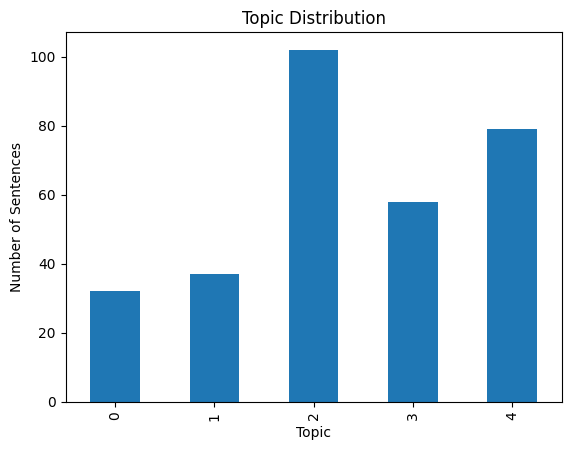

In [ ]:
pd.Series(labels).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Topic")
plt.ylabel("Number of Sentences")
plt.title("Topic Distribution")
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tn = "Helsinki-NLP/opus-mt-hi-en"
tt = AutoTokenizer.from_pretrained(tn)
tm = AutoModelForSeq2SeqLM.from_pretrained(tn).to(device)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [ ]:
x = tt(multi_summary, return_tensors="pt", truncation=True, max_length=512).to(device)
y = tm.generate(**x, max_length=300)
english = tt.decode(y[0], skip_special_tokens=True)

print(english)

13 8. VlMALS: The two corners of Angm-MOM's glacial dance have come to an end in the Middle Ages, they are not the only ones who have a circle.


In [ ]:
for b in [2,4,6]:
    y = tm.generate(**x, max_length=300, num_beams=b)
    print(f"\nBeams={b}\n{tt.decode(y[0], skip_special_tokens=True)}")


Beams=2
13 8. VlMS: In the middle of the days of Munda-Mooda-Magga-Masha-Magnan M-MOMOM'S D-MOM'S DIMMMARCH'S MARCHOCH, BMMMMMMMMMMMALMALGHO'S DlM MARCHOCK.

Beams=4
13 8. VlMMS: The two corners of Akm-MOM's marmoodum have come to an end in the Middle Ages, and in the image of the amandanda, they're not the only ones who have a circle.

Beams=6
13 8. VlMALS: The two corners of Angm-MOM's glacial dance have come to an end in the Middle Ages, they are not the only ones who have a circle.


In [ ]:
methods = ["TextRank","mT5","Multi-Doc","Query","Topic","Cross-Lingual"]

summaries = [
    textrank_results[pdf_files[0]],
    mt5(clean_documents[pdf_files[0]]),
    multi_summary,
    query_summary,
    " ".join(all_sentences[i] for i in np.where(labels == 0)[0][:5]),
    english
]

lengths = [len(s.split()) for s in summaries]

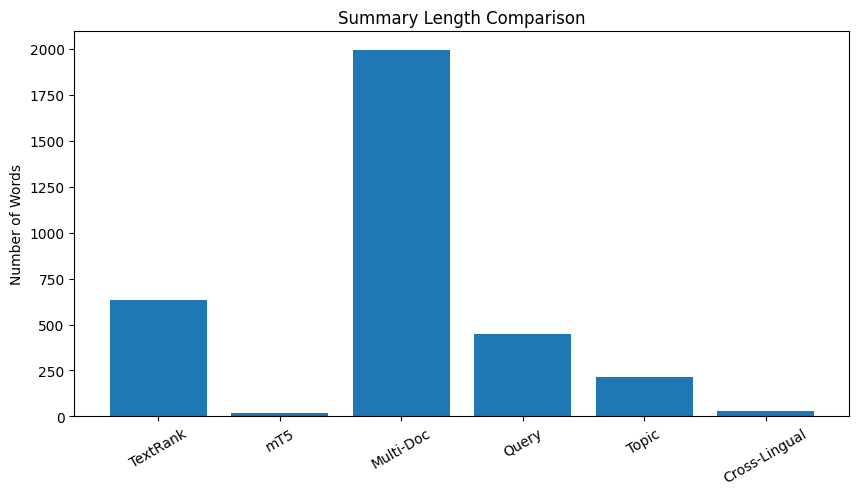

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(methods, lengths)
plt.ylabel("Number of Words")
plt.title("Summary Length Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
beams = [2,4,6]
scores = [len(tt.decode(tm.generate(**x,max_length=300,num_beams=b)[0],
                          skip_special_tokens=True).split()) for b in beams]

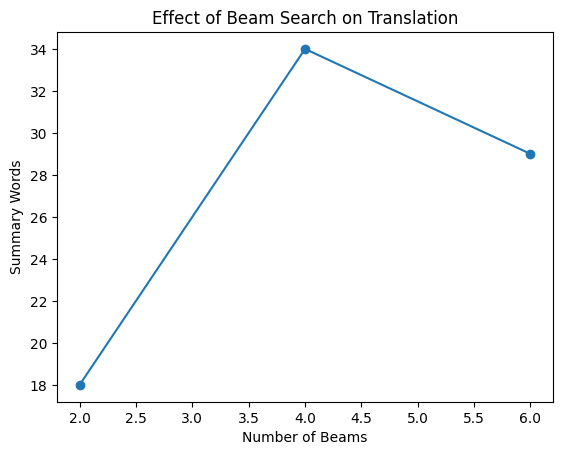

In [ ]:
plt.plot(beams, scores, marker="o")
plt.xlabel("Number of Beams")
plt.ylabel("Summary Words")
plt.title("Effect of Beam Search on Translation")
plt.show()

In [ ]:
counts = pd.Series(labels).value_counts().sort_index()

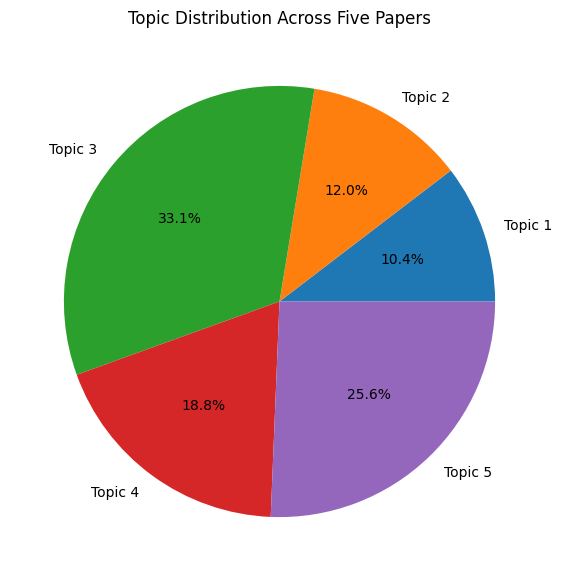

In [ ]:
plt.figure(figsize=(7,7))
plt.pie(counts, labels=[f"Topic {i+1}" for i in counts.index], autopct="%1.1f%%")
plt.title("Topic Distribution Across Five Papers")
plt.show()

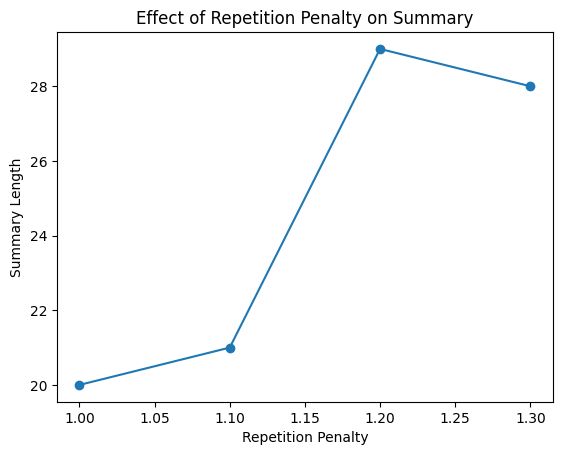

In [ ]:
p = [1.0,1.1,1.2,1.3]
w = [len(mt5(clean_documents[pdf_files[0]], penalty=x).split()) for x in p]

plt.plot(p,w,marker="o")
plt.xlabel("Repetition Penalty")
plt.ylabel("Summary Length")
plt.title("Effect of Repetition Penalty on Summary")
plt.show()